In [182]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix

import seaborn as sns


In [183]:
from ISLP import load_data
Default = load_data('Default')
Default.columns

Index(['default', 'student', 'balance', 'income'], dtype='object')

In [184]:
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [185]:
Default.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729272
max,2654.322576,73554.233495


In [186]:
Default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   default  10000 non-null  category
 1   student  10000 non-null  category
 2   balance  10000 non-null  float64 
 3   income   10000 non-null  float64 
dtypes: category(2), float64(2)
memory usage: 176.1 KB


In [187]:
# Füge Dummy Variablen hinzu für die Zielvariable 'default'
Default = pd.get_dummies(Default, columns=['default'])
Default.head()

,student,balance,income,default_No,default_Yes
0,No,729.526495,44361.625074,True,False
1,Yes,817.180407,12106.134700,True,False
2,No,1073.549164,31767.138947,True,False
3,No,529.250605,35704.493935,True,False
4,No,785.655883,38463.495879,True,False


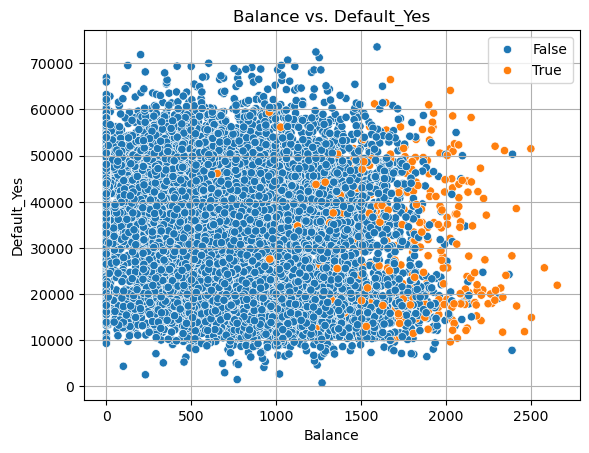

In [188]:
sns.scatterplot(data=Default, x='balance', y='income', hue='default_Yes')

# Add labels and title
plt.xlabel('Balance')
plt.ylabel('Default_Yes')
plt.title(f'Balance vs. Default_Yes')

# Show the legend and plot
plt.legend()
plt.grid()
plt.show()

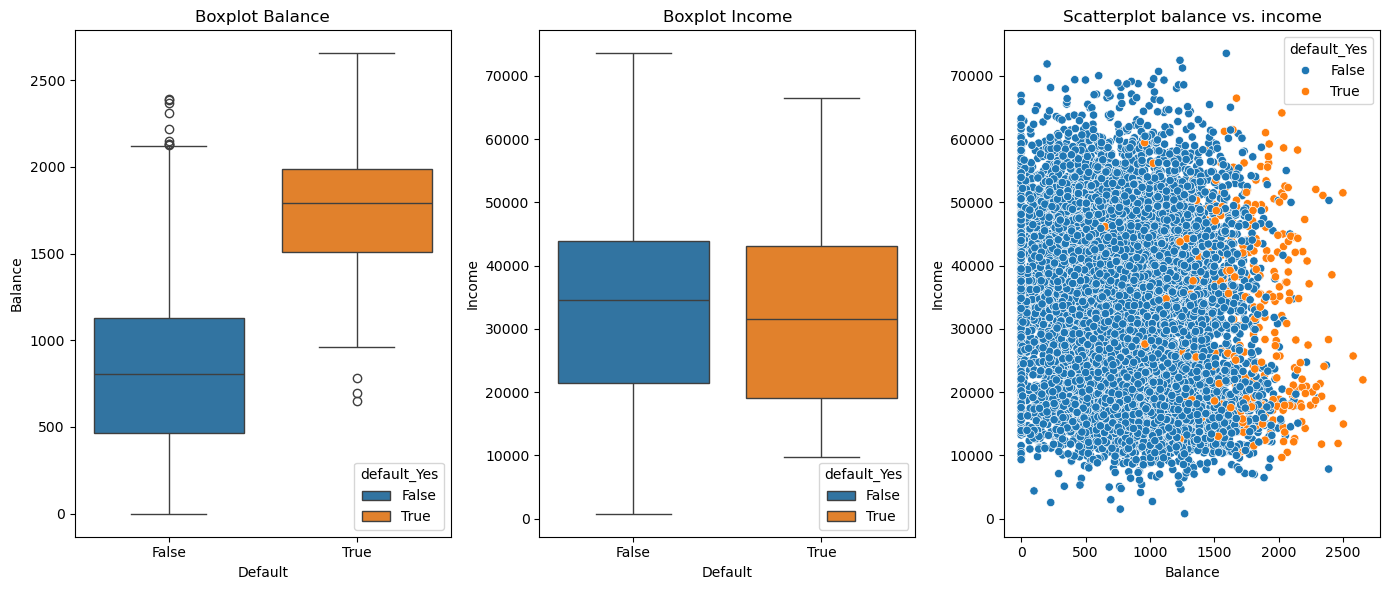

In [189]:
# Erstellen der Subplots (1 Zeile, 3 Spalten)
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Boxplot für 'balance' nach 'default'
sns.boxplot(x='default_Yes', y='balance', data=Default, hue='default_Yes', ax=axes[0])
axes[0].set_title('Boxplot Balance')
axes[0].set_xlabel('Default')
axes[0].set_ylabel('Balance')

# Boxplot für 'income' nach 'default'
sns.boxplot(x='default_Yes', y='income', data=Default, hue='default_Yes', ax=axes[1])
axes[1].set_title('Boxplot Income')
axes[1].set_xlabel('Default')
axes[1].set_ylabel('Income')


# Scatterplot für 'income' vs. 'balance' 
sns.scatterplot(data=Default, x='balance', y='income', hue='default_Yes')
axes[2].set_title('Scatterplot balance vs. income')
axes[2].set_xlabel('Balance')
axes[2].set_ylabel('Income')

# Layout anpassen und anzeigen
plt.tight_layout()
plt.show()


In [200]:
student_default = Default.groupby(['default_Yes', 'student'],observed=True).size()
print(student_default)

default_Yes  student
False        0          6850
             1          2817
True         0           206
             1           127
dtype: int64


Intercept: -0.07606698714746579
Coefficient for balance: 0.00013080278202817546
Test Mean Squared Error: 0.029665608400674486


/opt/anaconda3/envs/ISLP/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


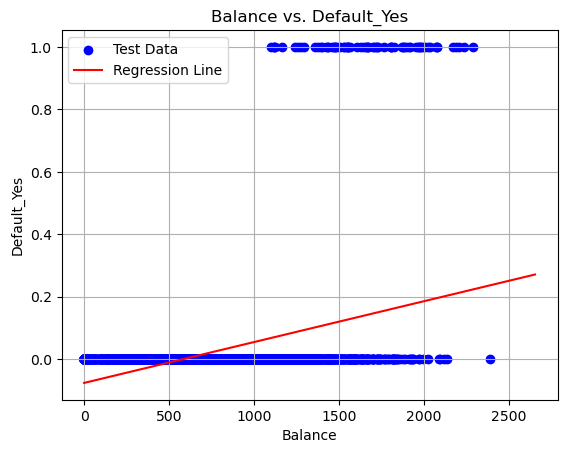

In [192]:
X = Default[['balance']]
y = Default['default_Yes']

# Split data into training and testing sets (using only training set for comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training der Modelle
lr_model = LinearRegression().fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print(f"Intercept: {lr_model.intercept_}")
print(f"Coefficient for balance: {lr_model.coef_[0]}")

mse = mean_squared_error(y_test, y_pred)
print(f"Test Mean Squared Error: {mse}")

# Scatterplot erstellen
plt.scatter(X_test, y_test, color='blue', label='Test Data')

# Get the regression line: predict across the range of X values
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_range_pred = lr_model.predict(X_range)


# Plot the regression line
plt.plot(X_range, y_range_pred, color='red', label=f'Regression Line')

# Add labels and title
plt.xlabel('Balance')
plt.ylabel('Default_Yes')
plt.title(f'Balance vs. Default_Yes')

# Show the legend and plot
plt.legend()
plt.grid()
plt.show()

Intercept: [-10.91699983]
Coefficient for balance: [0.00564782]


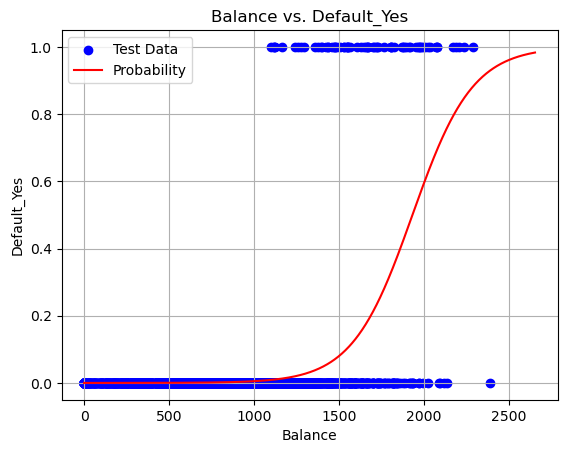

In [193]:
X = Default[['balance']] # balance ist die einzige Input Variable in diesem Beispiel
y = Default['default_Yes'].map({False: 0, True: 1}) 

# Split data into training and testing sets (using only training set for comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training der Modelle
logistic_model = LogisticRegression(penalty=None, random_state=0).fit(X_train, y_train, sample_weight=None)

y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print(f"Intercept: {logistic_model.intercept_}")
print(f"Coefficient for balance: {logistic_model.coef_[0]}")

# Scatterplot erstellen
plt.scatter(X_test, y_test, color='blue', label='Test Data')

# Get the regression line: predict across the range of X values
X_range = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)
X_range = pd.DataFrame(X_range, columns=X_train.columns)
y_range_pred_proba = logistic_model.predict_proba(X_range)[:, 1]
y_range_pred = logistic_model.predict(X_range)

# Plot the regression line
plt.plot(X_range, y_range_pred_proba, color='red', label=f'Probability')

# Labels and title
plt.xlabel('Balance')
plt.ylabel('Default_Yes')
plt.title(f'Balance vs. Default_Yes')

# Show the legend and plot
plt.legend()
plt.grid()
plt.show()

In [194]:

Default.student = pd.to_numeric(Default.student.map({'No': 0, 'Yes': 1}), errors='coerce')
print(Default.head())
X = Default.drop(columns=['default_Yes', 'default_No']) 
y = Default['default_Yes'].map({False: 0, True: 1}) 

# Split data into training and testing sets (using only training set for comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training der Modelle
logistic_model = LogisticRegression(penalty=None, random_state=0).fit(X_train, y_train, sample_weight=None)

y_pred = logistic_model.predict(X_test)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print(f"Intercept: {logistic_model.intercept_}")
print(f"Coefficient for student, balance: {logistic_model.coef_[0]}")


   student      balance        income  default_No  default_Yes
0        0   729.526495  44361.625074        True        False
1        1   817.180407  12106.134700        True        False
2        0  1073.549164  31767.138947        True        False
3        0   529.250605  35704.493935        True        False
4        0   785.655883  38463.495879        True        False
Intercept: [-11.3116964]
Coefficient for student, balance: [-4.88088327e-01  5.87826243e-03  7.21031152e-06]


In [195]:
# Modellkoeffizienten ausgeben
print("Intercept:")
print(logistic_model.intercept_)

print("\nKoeffizienten:")
print(
    pd.Series(
        logistic_model.coef_[0],
        index=X.columns
    )
)

Intercept:
[-11.3116964]

Koeffizienten:
student   -0.488088
balance    0.005878
income     0.000007
dtype: float64


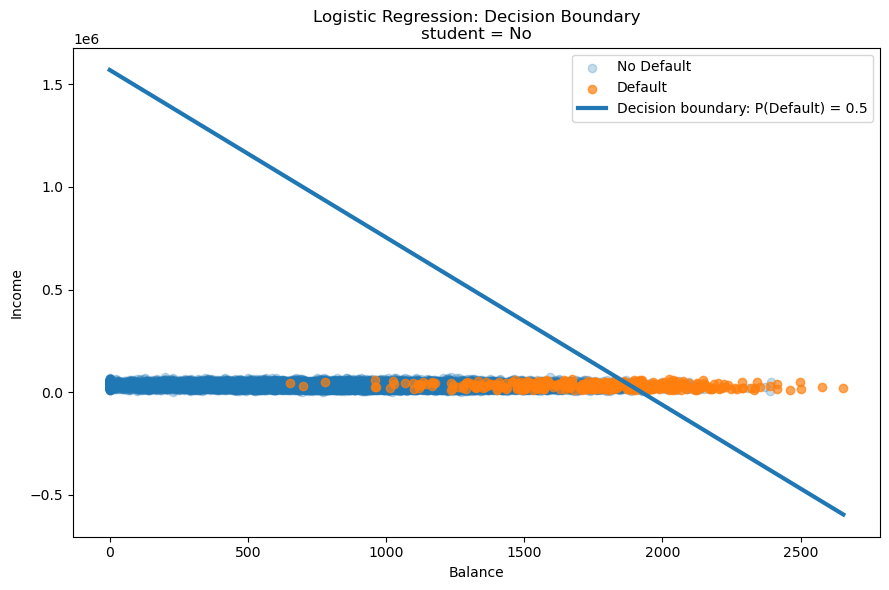

In [196]:
# Entscheidungsgrenze für student = 0

beta_0 = logistic_model.intercept_[0]
beta_student = logistic_model.coef_[0][0]
beta_balance = logistic_model.coef_[0][1]
beta_income = logistic_model.coef_[0][2]

income_boundary_no_student = -(
    beta_0
    + beta_student * 0
    + beta_balance * balance_grid
) / beta_income

beta_0 = logistic_model.intercept_[0]

# 0 = kein Student
# 1 = Student

fixed_student = 0


# Werte für die Trennlinie

balance_grid = np.linspace(
    Default["balance"].min(),
    Default["balance"].max(),
    300
)

income_boundary = -(
    beta_0
    + beta_student * fixed_student
    + beta_balance * balance_grid
) / beta_income

# Plot
fig, ax = plt.subplots(figsize=(9, 6))


# Kein Default
no_default = Default[
    Default["default_Yes"] == 0
]

ax.scatter(
    no_default["balance"],
    no_default["income"],
    alpha=0.25,
    label="No Default"
)

# Default
yes_default = Default[
    Default["default_Yes"] == 1
]

ax.scatter(
    yes_default["balance"],
    yes_default["income"],
    alpha=0.7,
    label="Default"
)

# Entscheidungsgrenze
ax.plot(
    balance_grid,
    income_boundary,
    linewidth=3,
    label="Decision boundary: P(Default) = 0.5"
)


ax.set_xlabel("Balance")
ax.set_ylabel("Income")

ax.set_title(
    "Logistic Regression: Decision Boundary\n"
    "student = No"
)

ax.legend()

plt.tight_layout()
plt.show()

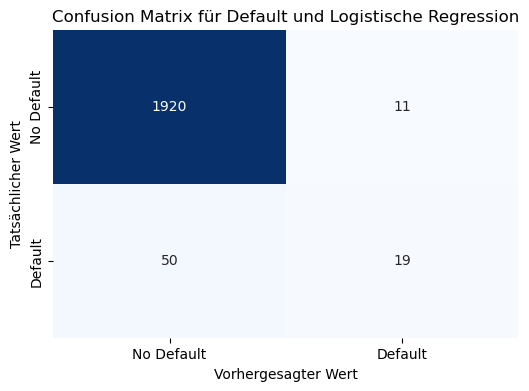

In [197]:
# Berechne die Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Zeichne die Confusion Matrix als Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix für Default und Logistische Regression')
plt.xlabel('Vorhergesagter Wert')
plt.ylabel('Tatsächlicher Wert')
plt.show()